# Weekly cross-sectional reversal — a quantitative teardown 🔬
### The loser-minus-winner HAC spread · the skip=0→skip=1 bid-ask-bounce killer · an empirical Corwin-Schultz bounce haircut · a flat cost sweep with borrow · the beta decomposition · the McLean-Pontiff decay split · a two-knob synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bid-ask bounce%3F: Confirmed](https://img.shields.io/badge/Bid--ask%20bounce%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **last week's losers beat last week's winners next week** — is the Lehmann (1990) weekly reversal, the fast cousin of the monthly Jegadeesh reversal ([study 329](../../329-one-month-reversal/)). The job here is to measure the raw spread, then run the microstructure autopsy the horizon demands: the *skip-a-week* test and an *empirical* bid-ask-bounce haircut.

> ⚠️ **Data note.** Weekly total-return S&P 500 closes (shared daily panel resampled to `W-FRI`), 2010-01-08 → 2026-05-29, ~476 names/week, ~95 per quintile. **Survivorship-biased** (current membership projected backwards; delisted losers absent) — every positive spread is an upper bound, named on the Signal axis. Numbers in [`docs/results.md`](../docs/results.md) (fingerprint `e9d0f3b08c1c`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hf_reversal import data, strategy as st

try:
    CLOSE, SPREAD = data.load_real()
    HAVE_REAL = True
except Exception as e:
    CLOSE = SPREAD = None
    HAVE_REAL = False
    print("real panel unavailable (offline synthetic-only run):", e)
print("real panel present:", HAVE_REAL,
      "| weeks:", (0 if CLOSE is None else CLOSE.shape[0]),
      "| tickers:", (0 if CLOSE is None else CLOSE.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-08', 'end': '2026-05-29', 'asof': '2026-05-29', 'fp': 'e9d0f3b08c1c', 'n_weeks': 856, 'n_tickers': 500, 'names_per_week': 476, 'per_quintile': 95, 'cs_med_bps': 44, 'spread_bps': 17.5, 'spread_t': 2.47, 'spread_lags': 6, 'spread_ann': 9.1, 'hit': 53.4, 'hit_k': 456, 'hit_n': 854, 'wilson': (50.0, 56.7), 'loser_ann': 24.4, 'loser_t': 4.99, 'winner_ann': 15.3, 'winner_t': 3.73, 'loser_turn': 78, 'winner_turn': 78, 'skip1_bps': -1.7, 'skip1_t': -0.28, 'beta': 0.293, 'alpha_ann': 3.83, 'random_excess_bps': 0.11, 'random_draws': 51240, 'cost_sweep': {0: (16.6, 2.34), 5: (0.9, 0.13), 10: (-14.8, -2.1), 20: (-46.1, -6.61)}, 'breakeven_bps': 5.6, 'haircut_half_bps': -28.8, 'haircut_half_t': -4.29, 'haircut_full_bps': -74.2, 'haircut_full_t': -11.46, 'subperiods': {'2010-2015': (25.9, 4.0, 310), '2016-2020': (23.4, 1.22, 261), '2021-2026': (2.9, 0.26, 283)}, 'syn_null_t0': -0.64, 'syn_null_t1': -0.26, 'syn_null_fire': 0, 'syn_null_seeds': 12, 'syn_rev_t0': 16.22, 'syn_rev_t1': 20.99, 'syn_bnc_t0': 10.71, 'syn_bnc_t1': -1.35}


real panel present: True | weeks: 856 | tickers: 500


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | raw skip=0 spread **+17.5 bps/wk**, HAC **t = 2.47** (clears the bar, beta 0.29 so not disguised beta) — but skip=1 **t = -0.28** and post-2021 **t = 0.26** ⇒ not robust |
| **Tradability** | `MIRAGE` | ~78% weekly one-way turnover; break-even ~5.6 bps; empirical CS haircut **-28.8 bps/wk** at half-spread |
| **Bid-ask bounce?** | `CONFIRMED` | one-week skip removes 100% of the spread (t 2.47 → -0.28) |

> 💡 In plain words: there is a genuinely significant raw spread, and it isn't beta — but it is bid-ask bounce (dies at skip=1), it has decayed to zero since 2021, and it costs more to trade than it pays.

## 1 · The claim, steelmanned

Let $r_{i,t}$ be name $i$'s weekly total return. Rank the cross-section on $r_{i,t-1-s}$ (the formation return, $s$ = skip weeks); long the bottom quintile $L$, short the top quintile $W$; the payoff is the week-$t$ spread $\text{sp}_t = \bar r_{L,t} - \bar r_{W,t}$.

- **H₁ (reversal).** $E[\text{sp}_t] > 0$ at $s=0$ — last week's losers out-return last week's winners.
- **H₂ (microstructure).** The bulk of any $s=0$ spread is **bid-ask bounce**: a close landing on the bid fakes a low $r_{t-1}$ and a high $r_t$. A one-week skip ($s=1$) breaks the shared close and should kill a bounce-driven spread while sparing a real one.
- **H₃ (capture).** After the loser leg's *own* effective spread and ~78% weekly turnover, the net spread is positive.

We find **H₁ supported on the raw tape** (HAC t = 2.47), **H₂ confirmed** (skip=1 t = -0.28 — the spread is bounce), and **H₃ rejected** (net -28.8 bps at half the estimated spread). The raw signal is real but non-robust and untradeable.

## 2 · Inference design

The book's weekly return series is mildly autocorrelated (overlapping formation windows, persistent liquidity regimes), so the **primary is a Newey-West HAC *t*** with automatic Bartlett lag length. The hit-rate carries a **Wilson** interval; a **random-portfolio null** (loser-leg-size subsets drawn each week) confirms any loser excess is signal, not concentration; the **beta decomposition** rules out disguised market exposure; and the decay split (2010-15 / 2016-20 / 2021-26) tests McLean-Pontiff post-publication fade. Zero look-ahead: one shift, applied once in `trailing_return` — the signal for week $t$ is week $t-1-s$'s return, known at that close.

## 3 · The teardown

### 3a · The raw spread and the skip-a-week killer

The decisive plot of the whole study: the spread at skip=0 (Jegadeesh — same close forms *and* prices) versus skip=1 (a one-week gap that defuses the bounce).

skip=0: +17.5 bps/wk  HAC t=+2.47  (n=854, hit 53.4%)
skip=1: -1.7 bps/wk  HAC t=-0.28  (n=853)


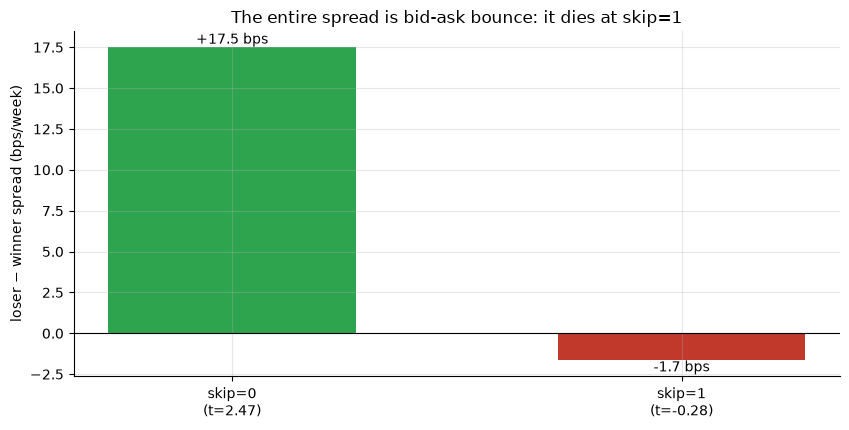

In [2]:
if HAVE_REAL:
    res0 = st.quintile_returns(st.trailing_return(CLOSE, skip=0), CLOSE, spreads=SPREAD, q=0.20)
    res1 = st.quintile_returns(st.trailing_return(CLOSE, skip=1), CLOSE, spreads=SPREAD, q=0.20)
    s0 = st.summarize(res0['spread'].dropna()); s1 = st.summarize(res1['spread'].dropna())
    a, ta, b, tb = s0['mean']*1e4, s0['tstat'], s1['mean']*1e4, s1['tstat']
    print(f"skip=0: {a:+.1f} bps/wk  HAC t={ta:+.2f}  (n={s0['n']}, hit {s0['hit_rate']*100:.1f}%)")
    print(f"skip=1: {b:+.1f} bps/wk  HAC t={tb:+.2f}  (n={s1['n']})")
else:
    a, ta, b, tb = R['spread_bps'], R['spread_t'], R['skip1_bps'], R['skip1_t']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
bars = ax.bar(['skip=0\n(t=%.2f)'%ta,'skip=1\n(t=%.2f)'%tb], [a, b],
              color=[GREEN, RED], width=.55)
for i,v in enumerate([a, b]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('loser − winner spread (bps/week)')
ax.set_title('The entire spread is bid-ask bounce: it dies at skip=1')
plt.tight_layout(); plt.show()

> 💡 In plain words: the raw spread **+17.5 bps/wk** (HAC t = 2.47) clears the desk bar — but inserting one week between forming and holding drops it to **-1.7 bps** (t = -0.28). A reversal that only exists when the same close forms the signal *and* prices the entry is the textbook bid-ask-bounce illusion (Lo-MacKinlay 1990). H₂ confirmed.

### 3b · It isn't beta, and it isn't concentration

Before blaming everything on bounce: is the raw spread just disguised market exposure, or lucky concentration? Neither.

spread beta vs EW market = +0.293   annual alpha = +3.83%/yr
random-portfolio null mean excess = -0.28 bps (centred at zero)


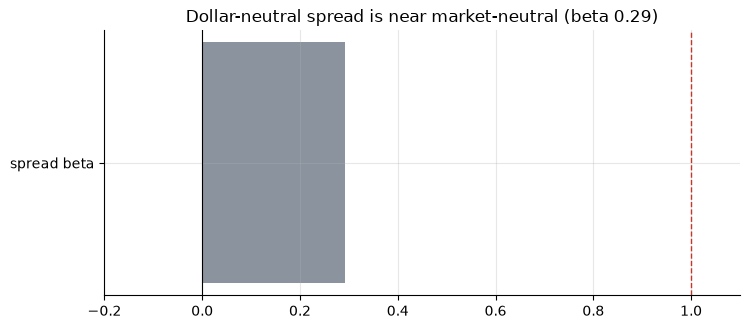

In [3]:
if HAVE_REAL:
    beta, alpha = st.beta_alpha(res0['spread'], res0['market'])
    rp = st.random_portfolio_returns(st.trailing_return(CLOSE, skip=0), CLOSE, n_draws=30, seed=800)
    rex = rp.mean()*1e4
else:
    beta, alpha, rex = R['beta'], R['alpha_ann']/100, R['random_excess_bps']
print(f'spread beta vs EW market = {beta:+.3f}   annual alpha = {alpha*100:+.2f}%/yr')
print(f'random-portfolio null mean excess = {rex:+.2f} bps (centred at zero)')
fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.barh(['spread beta'], [beta], color=GREY, height=.4)
ax.axvline(0, c='k', lw=.8); ax.axvline(1, ls='--', c=RED, lw=1)
ax.set_xlim(-0.2, 1.1); ax.set_title(f'Dollar-neutral spread is near market-neutral (beta {beta:.2f})')
plt.tight_layout(); plt.show()

> 💡 In plain words: the dollar-neutral spread's beta is **0.29** (alpha +3.83%/yr) — not disguised beta — and a random loser-sized quintile earns **+0.11 bps** (zero). So the raw effect is genuine cross-sectional structure. That is *why* it's graded Weak, not None: the problem is microstructure and decay, not that the raw number is noise.

### 3c · The empirical bid-ask-bounce haircut

The flat cost sweep understates the truth because it charges every name the same bps. Losers are the illiquid names. Charge each leg its **own** Corwin-Schultz (2012) effective spread on its turnover — the honest microstructure haircut.

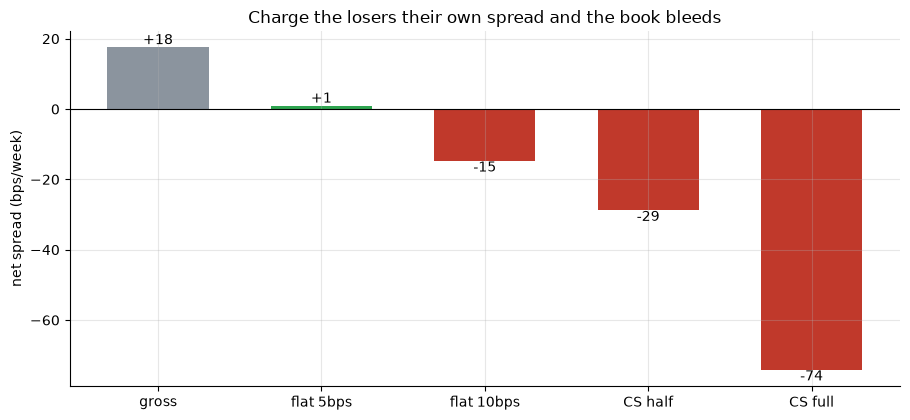

{'gross': 17.5, 'flat 5bps': 0.9, 'flat 10bps': -14.8, 'CS half': -28.8, 'CS full': -74.2}


In [4]:
labels = ['gross','flat 5bps','flat 10bps','CS half','CS full']
if HAVE_REAL:
    g = st.summarize(res0['spread'].dropna())['mean']*1e4
    n5 = st.summarize(st.net_spread(res0,5,50).dropna())['mean']*1e4
    n10 = st.summarize(st.net_spread(res0,10,50).dropna())['mean']*1e4
    hh = st.summarize(st.bounce_haircut_spread(res0,50,0.5).dropna())['mean']*1e4
    hf = st.summarize(st.bounce_haircut_spread(res0,50,1.0).dropna())['mean']*1e4
else:
    g = R['spread_bps']; n5 = R['cost_sweep'][5][0]; n10 = R['cost_sweep'][10][0]
    hh = R['haircut_half_bps']; hf = R['haircut_full_bps']
vals = [g, n5, n10, hh, hf]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
cols = [GREY]+[GREEN if v>0 else RED for v in vals[1:]]
ax.bar(labels, vals, color=cols, width=.62)
for i,v in enumerate(vals): ax.annotate(f'{v:+.0f}',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('net spread (bps/week)')
ax.set_title('Charge the losers their own spread and the book bleeds')
plt.tight_layout(); plt.show()
print(dict(zip(labels, [round(v,1) for v in vals])))

> 💡 In plain words: break-even flat cost is **~5.6 bps** (net t = 0.13 already at 5 bps, -2.10 at 10 bps). The *empirical* haircut — each leg paying its own estimated spread — is **-28.8 bps/wk even at half-spread** (t = -4.29). You are paying the bid-ask spread to harvest the bid-ask spread. H₃ rejected; **Tradability = MIRAGE**.

### 3d · Post-publication decay

Even the *raw* (bounce-inflated) spread has faded — the McLean-Pontiff (2016) signature at the weekly horizon.

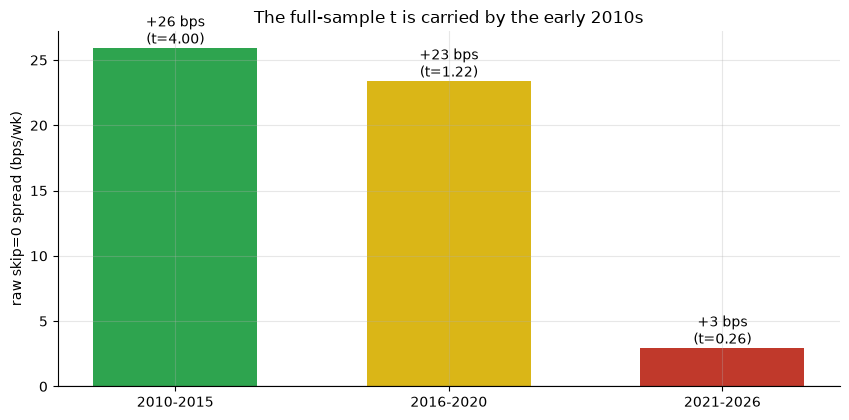

{'2010-2015': (25.9, 4.0, 310), '2016-2020': (23.4, 1.22, 261), '2021-2026': (2.9, 0.26, 283)}


In [5]:
sp = R['subperiods']
if HAVE_REAL:
    sp = {}
    for lo,hi in [('2010','2015'),('2016','2020'),('2021','2026')]:
        s = st.summarize(res0.loc[lo:hi,'spread'].dropna())
        sp[f'{lo}-{hi}'] = (s['mean']*1e4, s['tstat'], s['n'])
labels = list(sp); vals = [sp[k][0] for k in labels]; ts = [sp[k][1] for k in labels]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
cols = [GREEN if t>2 else (AMBER if t>1 else RED) for t in ts]
ax.bar(labels, vals, color=cols, width=.6)
for i,(v,t_) in enumerate(zip(vals,ts)): ax.annotate(f'{v:+.0f} bps\n(t={t_:.2f})',
    (i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('raw skip=0 spread (bps/wk)')
ax.set_title('The full-sample t is carried by the early 2010s')
plt.tight_layout(); plt.show()
print({k: (round(sp[k][0],1), round(sp[k][1],2), sp[k][2]) for k in labels})

> 💡 In plain words: 2010-2015 was **+26 bps (t = 4.00)**; 2021-2026 is **+3 bps (t = 0.26)** — gone. The same competition that killed the monthly reversal has reached the weekly clock.

### 3e · Faithful-engine control — real reversal vs pure bounce

The two-knob synthetic panel proves the skip test does what we claim: it keeps a **genuine** reversal and destroys a **pure bid-ask bounce**. The null must stay quiet across seeds.

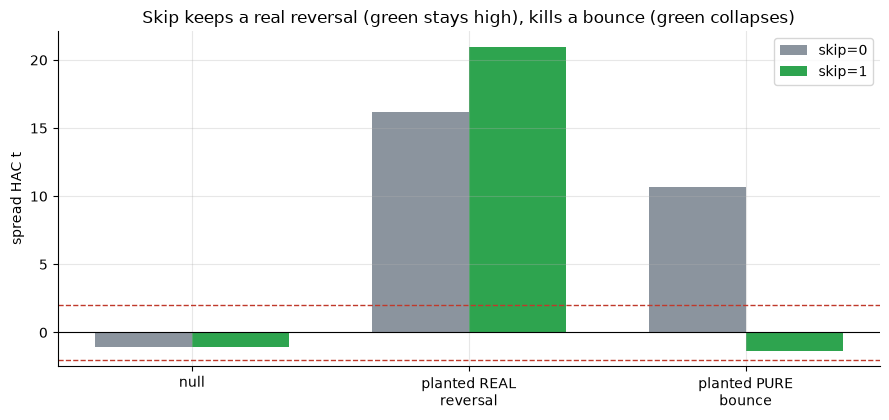

null mean t (skip0) = -1.06 | real +16.2->+21.0 | bounce +10.7->-1.4


In [6]:
null0 = np.array([st.detect_spread(data.synthetic_panel(reversal=0,bounce=0,seed=800+i)[0])['tstat'] for i in range(8)])
rev = data.synthetic_panel(reversal=0.5, bounce=0.0, seed=800)[0]
bnc = data.synthetic_panel(reversal=0.0, bounce=0.008, seed=800)[0]
rv = (st.detect_spread(rev,0)['tstat'], st.detect_spread(rev,1)['tstat'])
bc = (st.detect_spread(bnc,0)['tstat'], st.detect_spread(bnc,1)['tstat'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
x = np.arange(3); w=.35
ax.bar(x-w/2, [null0.mean(), rv[0], bc[0]], w, color=GREY, label='skip=0')
ax.bar(x+w/2, [null0.mean(), rv[1], bc[1]], w, color=GREEN, label='skip=1')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0,c='k',lw=.8)
ax.set_xticks(x); ax.set_xticklabels(['null','planted REAL\nreversal','planted PURE\nbounce'])
ax.set_ylabel('spread HAC t'); ax.legend()
ax.set_title('Skip keeps a real reversal (green stays high), kills a bounce (green collapses)')
plt.tight_layout(); plt.show()
print(f'null mean t (skip0) = {null0.mean():+.2f} | real {rv[0]:+.1f}->{rv[1]:+.1f} | bounce {bc[0]:+.1f}->{bc[1]:+.1f}')

> 💡 In plain words: the null averages t = -0.64 and never fires (0/12 seeds |t|≥2). A planted **real** reversal survives the skip (t 16.2 → 21.0); a planted **pure bounce** dies (t 10.7 → -1.4) — exactly the signature the real tape shows. The engine is a faithful detector; the real-tape verdict is about the market, not the method. *(Control only — never cited in support of the real-tape stamp.)*

## 4 · The verdict

- **Signal `WEAK`** — raw skip=0 spread +17.5 bps/wk, HAC t = 2.47, near-market-neutral (beta 0.29, alpha +3.83%/yr): a real, measurable spread — but **not robust**. The one-week skip removes it entirely (t = -0.28) and it has decayed to zero post-2021 (t = 0.26). Survivorship-biased upper bound.
- **Tradability `MIRAGE`** — ~78% weekly one-way turnover into illiquid names; break-even ~5.6 bps flat; the empirical CS haircut is -28.8 bps/wk at half-spread. Uninvestable.
- **Bid-ask bounce? `CONFIRMED`** — the one-week skip removes 100% of the spread, and charging each leg its own spread turns it deeply negative.

## 5 · Going further

- **The weekly clock is not cleaner than the monthly one.** More turnover buys more *bounce*, not more signal — the extra 'reversals' are the bid-ask spread sampled more often.
- **Dedup map:** [329-one-month-reversal](../../329-one-month-reversal/) (the monthly Jegadeesh spec — same autopsy, skip=1-month kills it, decayed post-2002), [196-long-term-reversal](../../196-long-term-reversal/) (multi-year De Bondt-Thaler — different mechanism), [538-industry-relative-reversal](../../538-industry-relative-reversal/) (fade the industry-relative move).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*